In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q findspark
import findspark
findspark.init()

In [2]:

from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

spark = (
    SparkSession.builder
    .appName("pyspark-Validation_Randomforest")
    .master("local[*]")
    .config('spark.ui.port', '4050')
    .config("spark.driver.memory", "35g")
    .config("spark.driver.memoryOverhead", "4g")

    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")

    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")

    .getOrCreate()
)

spark


In [ ]:
# spark.stop()

In [ ]:
!pip install -q ngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.9 MB/s eta 0:00:00


In [ ]:
!wget -q https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz
!tar -xzf ngrok-v3-stable-linux-amd64.tgz
!chmod +x ngrok
get_ipython().system_raw('!./ngrok http 4050 &')


In [ ]:
!./ngrok authtoken 372K2OENTZEIyObJBECpiQP0wUR_BgEkQykJerjtRoPQJsoH

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!nohup ./ngrok http 4050 --log=stdout --log-format=logfmt > ngrok.log 2>&1 &


In [3]:
parquet_path_raw = "/content/drive/MyDrive/bigdata/cic_ddos_raw.parquet"
parquet_path_25 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_25.parquet"
parquet_path_21 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_21.parquet"
parquet_path_27 = r"/content/drive/MyDrive/bigdata/cic_ddos_rf_27.parquet"

df_feature_raw = spark.read.parquet(parquet_path_raw).cache()
df_feature_25 = spark.read.parquet(parquet_path_25).cache()
df_feature_21 = spark.read.parquet(parquet_path_21).cache()
df_feature_27 = spark.read.parquet(parquet_path_27).cache()

df_feature_25.printSchema(), df_feature_21.printSchema(), df_feature_27.printSchema(), df_feature_raw.printSchema()

root
 |-- pca_k25: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- pca_k21: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- label: string (nullable = true)
 |-- rf_27: vector (nullable = true)

root
 |-- features: vector (nullable = true)
 |-- label: string (nullable = true)



(None, None, None, None)

In [4]:
from pyspark.ml.feature import StringIndexer
label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)
df_indexed_25 = label_indexer.fit(df_feature_25).transform(df_feature_25)
df_indexed_21 = label_indexer.fit(df_feature_21).transform(df_feature_21)
df_indexed_27 = label_indexer.fit(df_feature_27).transform(df_feature_27)
df_indexed_raw = label_indexer.fit(df_feature_raw).transform(df_feature_raw)


In [5]:
from pyspark.sql.functions import lit

def split_train_test(df_indexed):
  fractions = (
      df_indexed
      .select("label")
      .distinct()
      .withColumn("fraction", lit(0.02))
      .rdd.collectAsMap()
  )

  test_df = df_indexed.sampleBy(
      "label",
      fractions,
      seed=42
  )
  return test_df, df_indexed.subtract(test_df)

test_df_25, train_df_25 = split_train_test(df_indexed_25)
test_df_21, train_df_21 = split_train_test(df_indexed_21)
test_df_27, train_df_27 = split_train_test(df_indexed_27)
test_df_raw, train_df_raw = split_train_test(df_indexed_raw)

In [6]:
from pyspark.ml.classification import RandomForestClassificationModel

rf_model_raw_path = r"/content/drive/MyDrive/bigdata/model/rf_cic_ddos_2019_raw"
rf_model_25_path  = r"/content/drive/MyDrive/bigdata/model/rf_cic_ddos_2019_pca_k25"
rf_model_21_path  = r"/content/drive/MyDrive/bigdata/model/rf_cic_ddos_2019_pca_k21"
rf_model_27_path  = r"/content/drive/MyDrive/bigdata/model/rf_cic_ddos_2019_rf_k27"

rf_model_raw = RandomForestClassificationModel.load(rf_model_raw_path)
rf_model_21  = RandomForestClassificationModel.load(rf_model_21_path)
rf_model_25  = RandomForestClassificationModel.load(rf_model_25_path)
rf_model_27  = RandomForestClassificationModel.load(rf_model_27_path)


In [7]:
df_pred_raw = rf_model_raw.transform(test_df_raw)
df_pred_k21 = rf_model_21.transform(test_df_21)
df_pred_k25 = rf_model_25.transform(test_df_25)
df_pred_k27 = rf_model_27.transform(test_df_27)


# Acc,F1,Recall,Precision

In [8]:
from sklearn.metrics import classification_report

def evaluate(pdf):
    print(
        classification_report(
            pdf["label_index"],
            pdf["prediction"],
            digits=4
        )
    )

pdf_raw = df_pred_raw.select("label_index", "prediction").toPandas()
pdf_21  = df_pred_k21.select("label_index", "prediction").toPandas()
pdf_25  = df_pred_k25.select("label_index", "prediction").toPandas()
pdf_27  = df_pred_k27.select("label_index", "prediction").toPandas()

print("RAW")
evaluate(pdf_raw)

print("K21")
evaluate(pdf_21)

print("K25")
evaluate(pdf_25)

print("K27")
evaluate(pdf_27)


RAW
              precision    recall  f1-score   support

         0.0     0.7601    0.8446    0.8001    102744
         1.0     0.8364    0.4900    0.6180    101098
         2.0     0.9861    0.9911    0.9886     90326
         3.0     0.9414    0.9845    0.9625     81979
         4.0     0.3681    0.5885    0.4529     43215
         5.0     0.8663    0.9990    0.9279     31881
         6.0     0.9903    0.9969    0.9936     24211
         7.0     0.9026    0.3121    0.4638      7187
         8.0     0.9982    1.0000    0.9991       555
         9.0     0.4091    1.0000    0.5806         9

    accuracy                         0.8087    483205
   macro avg     0.8059    0.8207    0.7787    483205
weighted avg     0.8349    0.8087    0.8071    483205

K21
              precision    recall  f1-score   support

         0.0     0.7590    0.8561    0.8046    102639
         1.0     0.7892    0.4654    0.5856    100934
         2.0     0.9772    0.9912    0.9842     90568
         3.0    

# confusion_matrix

In [9]:
from pyspark.ml.feature import StringIndexer

label_indexer_raw = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_indexer_21 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_indexer_25 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_indexer_27 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_model_raw = label_indexer_raw.fit(df_feature_raw)
label_model_21  = label_indexer_21.fit(df_feature_21)
label_model_25  = label_indexer_25.fit(df_feature_25)
label_model_27  = label_indexer_27.fit(df_feature_27)

df_indexed_raw = label_model_raw.transform(df_feature_raw)
df_indexed_21  = label_model_21.transform(df_feature_21)
df_indexed_25  = label_model_25.transform(df_feature_25)
df_indexed_27  = label_model_27.transform(df_feature_27)


In [10]:
def build_label_map(label_model):
    return spark.createDataFrame(
        [(i, l) for i, l in enumerate(label_model.labels)],
        ["label_index", "label_name"]
    )

label_map_raw = build_label_map(label_model_raw)
label_map_21  = build_label_map(label_model_21)
label_map_25  = build_label_map(label_model_25)
label_map_27  = build_label_map(label_model_27)


In [11]:
from pyspark.sql import functions as F

def confusion_matrix_2d(df, label_col="label_index", pred_col="prediction"):
    return (
        df
        .groupBy(label_col, pred_col)
        .count()
        .groupBy(label_col)
        .pivot(pred_col)
        .sum("count")
        .na.fill(0)
        .orderBy(label_col)
    )


In [12]:
def attach_label_name(cm_df, label_map):
    return (
        cm_df
        .join(label_map, on="label_index", how="left")
        .orderBy("label_index")
    )

cm_raw = attach_label_name(
    confusion_matrix_2d(df_pred_raw),
    label_map_raw
)

cm_k21 = attach_label_name(
    confusion_matrix_2d(df_pred_k21),
    label_map_21
)

cm_k25 = attach_label_name(
    confusion_matrix_2d(df_pred_k25),
    label_map_25
)

cm_k27 = attach_label_name(
    confusion_matrix_2d(df_pred_k27),
    label_map_27
)


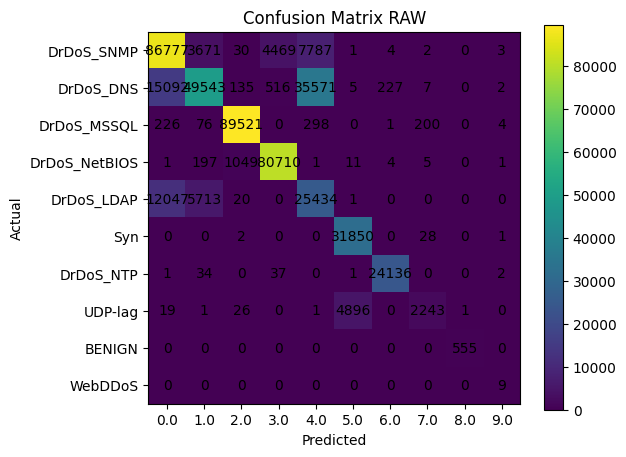

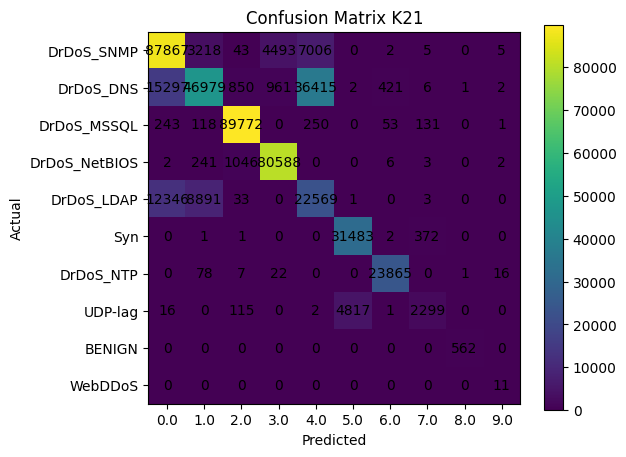

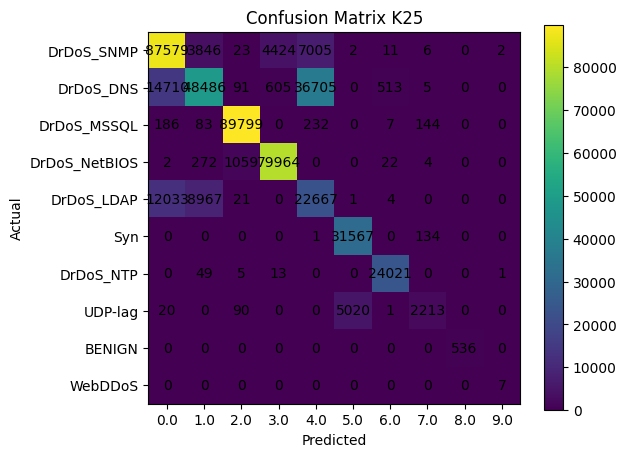

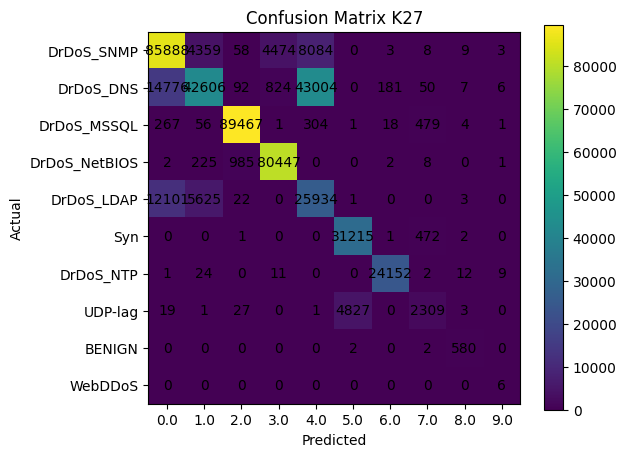

In [13]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm_spark, title):
    pdf = cm_spark.toPandas()

    y_labels = pdf["label_name"]
    pdf = pdf.drop(columns=["label_index", "label_name"])
    mat = pdf.values

    plt.figure(figsize=(6, 5))
    plt.imshow(mat)
    plt.colorbar()
    plt.xticks(range(mat.shape[1]), pdf.columns)
    plt.yticks(range(mat.shape[0]), y_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, int(mat[i, j]), ha="center", va="center")

    plt.show()
plot_confusion_matrix(cm_raw, "Confusion Matrix RAW")
plot_confusion_matrix(cm_k21, "Confusion Matrix K21")
plot_confusion_matrix(cm_k25, "Confusion Matrix K25")
plot_confusion_matrix(cm_k27, "Confusion Matrix K27")
